# Comprehensive Results Audit

This notebook analyzes the saved benchmark outputs currently present in the repo.

Primary goals:

1. compare accuracy across the saved method runs
2. compare performance and token cost
3. inspect concrete example-level behaviors without hallucinating beyond saved outputs
4. summarize what the current results do and do not support

Verified saved roots used here:

- `outputs_meeting_core/subset`: `vanilla_rag`, `dos_rag`
- `outputs_meeting_raptor15/subset`: `raptor`
- `outputs/subset`: older `vanilla_rag` / `dos_rag` subset rerun, treated as a secondary appendix run

Important caveat:

- I did **not** find a distinct output directory explicitly named `longbench` or `long_context`.
- If `outputs/subset` is the intended "long bench" run, the appendix below summarizes it explicitly.
- The fairest direct comparison with RAPTOR is on the **shared 15-example overlap** for `qasper`, `narrative_qa`, `quality`, and `contract_nli`.


In [1]:
from pathlib import Path
import json
import sys
from statistics import mean

import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ModuleNotFoundError:
    def display(obj):
        print(obj)


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "benchmarking").exists() and (candidate / "outputs_meeting_core").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repo root from the current working directory.")


ROOT = find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from benchmarking.metrics import compute_metrics

RUNS = {
    "meeting_core": {
        "root": ROOT / "outputs_meeting_core" / "subset",
        "note": "vanilla_rag + dos_rag, 50 examples per task",
    },
    "raptor15": {
        "root": ROOT / "outputs_meeting_raptor15" / "subset",
        "note": "raptor only, 15 examples per task",
    },
    "legacy_subset": {
        "root": ROOT / "outputs" / "subset",
        "note": "older vanilla_rag + dos_rag subset rerun",
    },
}
RUNS = {name: cfg for name, cfg in RUNS.items() if cfg["root"].exists()}


def load_json(path):
    with open(path) as fh:
        return json.load(fh)


def load_jsonl(path):
    rows = []
    with open(path) as fh:
        for line in fh:
            if line.strip():
                rows.append(json.loads(line))
    return rows


def method_dirs(run_root):
    return sorted([d for d in run_root.iterdir() if d.is_dir() and d.name != "analysis"], key=lambda p: p.name)


def score_row(task, row):
    return compute_metrics([row.get("prediction", "")], [row.get("references", [])], task_name=task).get("scrolls_score", 0.0)


def summary_primary_score(summary):
    metrics = summary.get("metrics", {})
    if "scrolls_score" in metrics:
        return float(metrics["scrolls_score"])

    display = summary.get("display", [])
    if display:
        first = display[0]
        if isinstance(first, dict) and "value" in first:
            return float(first["value"])
        if isinstance(first, (int, float)):
            return float(first)

    for key in summary.get("display_keys", []):
        if key in metrics and isinstance(metrics[key], (int, float)):
            return float(metrics[key])

    for value in metrics.values():
        if isinstance(value, (int, float)):
            return float(value)

    raise KeyError("No numeric task score found in summary metrics.")


print("Repo root:", ROOT)
for name, cfg in RUNS.items():
    print(name, "->", cfg["root"], "|", cfg["note"])


Repo root: /home/yifan/FORWARD Data Lab/long-document-qa-baseline
meeting_core -> /home/yifan/FORWARD Data Lab/long-document-qa-baseline/outputs_meeting_core/subset | vanilla_rag + dos_rag, 50 examples per task
raptor15 -> /home/yifan/FORWARD Data Lab/long-document-qa-baseline/outputs_meeting_raptor15/subset | raptor only, 15 examples per task
legacy_subset -> /home/yifan/FORWARD Data Lab/long-document-qa-baseline/outputs/subset | older vanilla_rag + dos_rag subset rerun


## Run Discovery

This section confirms exactly which methods and tasks are present in each saved output root.


In [2]:
discovery_rows = []
for run_name, cfg in RUNS.items():
    for method_dir in method_dirs(cfg["root"]):
        task_dirs = sorted([d.name for d in method_dir.iterdir() if d.is_dir()])
        discovery_rows.append(
            {
                "run": run_name,
                "method": method_dir.name,
                "tasks": ", ".join(task_dirs),
                "num_tasks": len(task_dirs),
                "note": cfg["note"],
            }
        )

discovery_df = pd.DataFrame(discovery_rows)
display(discovery_df)


,run,method,tasks,num_tasks,note
0,meeting_core,dos_rag,"contract_nli, narrative_qa, qasper, qmsum, qua...",5,"vanilla_rag + dos_rag, 50 examples per task"
1,meeting_core,vanilla_rag,"contract_nli, narrative_qa, qasper, qmsum, qua...",5,"vanilla_rag + dos_rag, 50 examples per task"
2,raptor15,raptor,"contract_nli, narrative_qa, qasper, quality",4,"raptor only, 15 examples per task"
3,legacy_subset,dos_rag,"contract_nli, narrative_qa, qasper, qmsum, qua...",5,older vanilla_rag + dos_rag subset rerun
4,legacy_subset,vanilla_rag,"contract_nli, narrative_qa, qasper, qmsum, qua...",5,older vanilla_rag + dos_rag subset rerun


## Task-Level Accuracy and Performance Summary

The table below is built directly from each task's saved `summary.json`.

Important caution:

- `vanilla_rag` and `dos_rag` in `meeting_core` are 50-example subset runs.
- `raptor` is only a 15-example subset run.
- So raw task-level scores are informative, but not always directly apples-to-apples.


In [3]:
summary_rows = []
for run_name, cfg in RUNS.items():
    for method_dir in method_dirs(cfg["root"]):
        for summary_path in sorted(method_dir.glob('*/summary.json')):
            summary = load_json(summary_path)
            num_examples = summary.get("num_examples", 0)
            elapsed = float(summary.get("elapsed_seconds", 0.0))
            summary_rows.append(
                {
                    "run": run_name,
                    "method": method_dir.name,
                    "task": summary["task"],
                    "metric": summary["metric_type"],
                    "num_examples": num_examples,
                    "score": summary_primary_score(summary),
                    "elapsed_seconds": elapsed,
                    "seconds_per_example": elapsed / num_examples if num_examples else None,
                    "avg_input_tokens": float(summary["token_stats"].get("avg_input_tokens", 0.0)),
                    "avg_context_tokens": float(summary["token_stats"].get("avg_context_tokens", 0.0)),
                    "avg_generation_tokens": float(summary["token_stats"].get("avg_generation_tokens", 0.0)),
                }
            )

summary_df = pd.DataFrame(summary_rows).sort_values(["run", "method", "task"])
display(summary_df)


,run,method,task,metric,num_examples,score,elapsed_seconds,seconds_per_example,avg_input_tokens,avg_context_tokens,avg_generation_tokens
14,legacy_subset,dos_rag,contract_nli,exact_match,50,64.000000,17.01,0.340200,3950.000000,3842.040000,2.600000
15,legacy_subset,dos_rag,narrative_qa,f1,50,11.765116,177.44,3.548800,10083.760000,9951.960000,17.480000
16,legacy_subset,dos_rag,qasper,f1,50,47.050784,29.50,0.590000,5578.760000,5449.840000,18.640000
17,legacy_subset,dos_rag,qmsum,rouge,50,32.163595,165.28,3.305600,9105.500000,9049.060000,158.860000
18,legacy_subset,dos_rag,quality,exact_match,50,76.000000,29.61,0.592200,6484.340000,6310.760000,15.320000
19,legacy_subset,vanilla_rag,contract_nli,exact_match,50,72.000000,65.28,1.305600,3950.000000,3842.040000,2.700000
20,legacy_subset,vanilla_rag,narrative_qa,f1,50,11.372744,174.39,3.487800,10083.760000,9951.960000,12.740000
21,legacy_subset,vanilla_rag,qasper,f1,50,43.057548,55.00,1.100000,5578.760000,5449.840000,15.880000
22,legacy_subset,vanilla_rag,qmsum,rouge,50,31.330751,248.59,4.971800,9105.500000,9049.060000,151.220000
23,legacy_subset,vanilla_rag,quality,exact_match,50,70.000000,110.18,2.203600,6484.340000,6310.760000,15.180000


## Accuracy Visualization

This plot shows reported task scores for the main saved comparison roots:

- `meeting_core`: `vanilla_rag`, `dos_rag`
- `raptor15`: `raptor`

RAPTOR is marked with `n=15`, while the meeting-core runs are `n=50`.


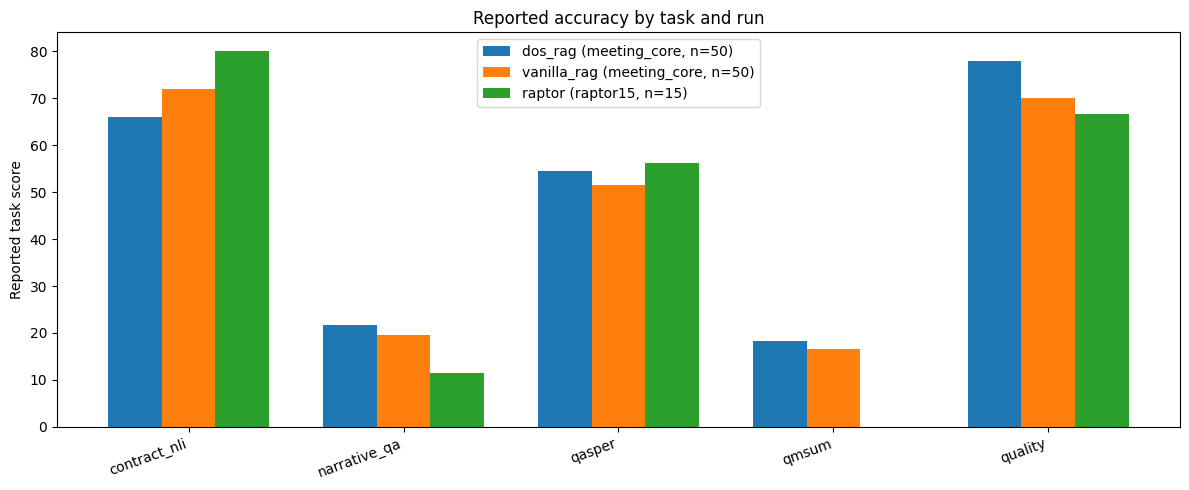

,run,method,task,num_examples,score
0,meeting_core,dos_rag,contract_nli,50,66.0000
5,meeting_core,vanilla_rag,contract_nli,50,72.0000
10,raptor15,raptor,contract_nli,15,80.0000
1,meeting_core,dos_rag,narrative_qa,50,21.6398
6,meeting_core,vanilla_rag,narrative_qa,50,19.5300
11,raptor15,raptor,narrative_qa,15,11.4620
2,meeting_core,dos_rag,qasper,50,54.4233
7,meeting_core,vanilla_rag,qasper,50,51.4486
12,raptor15,raptor,qasper,15,56.2477
3,meeting_core,dos_rag,qmsum,50,18.2178


In [4]:
plot_df = summary_df[summary_df["run"].isin(["meeting_core", "raptor15"])].copy()
plot_df["label"] = plot_df["method"] + " (" + plot_df["run"] + ", n=" + plot_df["num_examples"].astype(str) + ")"

tasks = list(dict.fromkeys(plot_df["task"].tolist()))
labels = list(dict.fromkeys(plot_df["label"].tolist()))
x = range(len(tasks))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
for idx, label in enumerate(labels):
    ys = []
    for task in tasks:
        rows = plot_df[(plot_df["task"] == task) & (plot_df["label"] == label)]
        ys.append(rows.iloc[0]["score"] if not rows.empty else float('nan'))
    offset = (idx - (len(labels) - 1) / 2) * width
    ax.bar([i + offset for i in x], ys, width=width, label=label)

ax.set_xticks(list(x))
ax.set_xticklabels(tasks, rotation=20, ha="right")
ax.set_ylabel("Reported task score")
ax.set_title("Reported accuracy by task and run")
ax.legend()
plt.tight_layout()
plt.show()

display(plot_df[["run", "method", "task", "num_examples", "score"]].sort_values(["task", "run", "method"]))


## Performance Visualization

Here performance is normalized as `seconds_per_example`, which is the fairest simple comparison across runs with different sample counts.

I also include average prompt input tokens because some methods are trading speed against prompt size.


,run,method,total_examples,total_seconds,seconds_per_example,weighted_avg_input_tokens
0,meeting_core,dos_rag,250,1909.83,7.63932,6895.852000
1,meeting_core,vanilla_rag,250,972.25,3.88900,6922.324000
2,raptor15,raptor,60,9588.48,159.80800,7068.483333


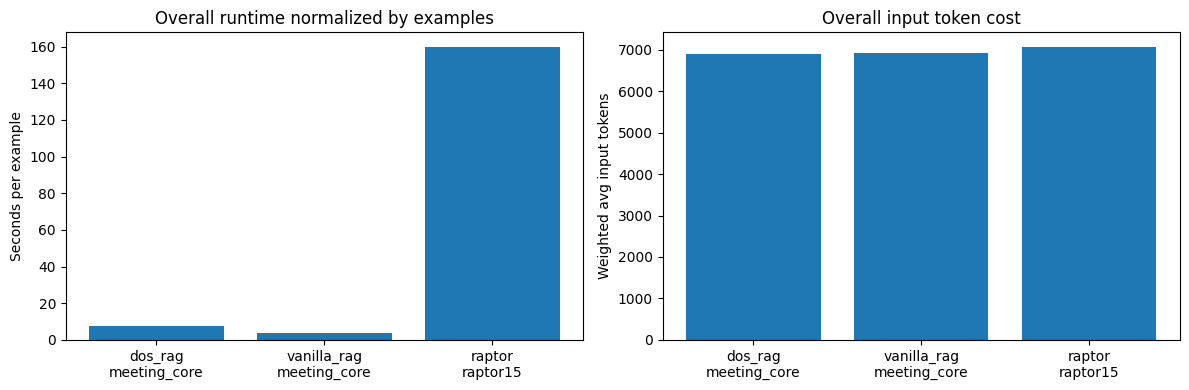

,run,method,task,num_examples,seconds_per_example,avg_input_tokens
0,meeting_core,dos_rag,contract_nli,50,0.726600,3977.500000
5,meeting_core,vanilla_rag,contract_nli,50,1.302800,3950.000000
10,raptor15,raptor,contract_nli,15,47.288000,2982.933333
1,meeting_core,dos_rag,narrative_qa,50,22.500400,9713.140000
6,meeting_core,vanilla_rag,narrative_qa,50,9.221400,10084.120000
11,raptor15,raptor,narrative_qa,15,354.358000,10180.333333
2,meeting_core,dos_rag,qasper,50,1.907800,5029.380000
7,meeting_core,vanilla_rag,qasper,50,1.733000,4987.660000
12,raptor15,raptor,qasper,15,129.025333,6954.200000
3,meeting_core,dos_rag,qmsum,50,11.307200,9159.660000


In [5]:
perf_df = summary_df[summary_df["run"].isin(["meeting_core", "raptor15"])].copy()

overall_rows = []
for (run, method), group in perf_df.groupby(["run", "method"]):
    total_seconds = group["elapsed_seconds"].sum()
    total_examples = group["num_examples"].sum()
    overall_rows.append(
        {
            "run": run,
            "method": method,
            "total_examples": int(total_examples),
            "total_seconds": float(total_seconds),
            "seconds_per_example": total_seconds / total_examples if total_examples else None,
            "weighted_avg_input_tokens": (group["avg_input_tokens"] * group["num_examples"]).sum() / total_examples if total_examples else None,
        }
    )

overall_perf_df = pd.DataFrame(overall_rows).sort_values(["run", "method"])
display(overall_perf_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(overall_perf_df["method"] + "\n" + overall_perf_df["run"], overall_perf_df["seconds_per_example"])
axes[0].set_ylabel("Seconds per example")
axes[0].set_title("Overall runtime normalized by examples")

axes[1].bar(overall_perf_df["method"] + "\n" + overall_perf_df["run"], overall_perf_df["weighted_avg_input_tokens"])
axes[1].set_ylabel("Weighted avg input tokens")
axes[1].set_title("Overall input token cost")

plt.tight_layout()
plt.show()

display(perf_df[["run", "method", "task", "num_examples", "seconds_per_example", "avg_input_tokens"]].sort_values(["task", "run", "method"]))


## Aggregate Accuracy / Performance Tradeoff

This condenses the saved runs into one view: weighted average task score, normalized runtime, and average token cost.

Use it as an efficiency snapshot, then rely on the overlap analysis below for the fairest RAPTOR comparison.


,run,method,total_examples,weighted_score,seconds_per_example,weighted_avg_input_tokens
1,meeting_core,vanilla_rag,250,45.92582,3.88900,6922.324000
0,meeting_core,dos_rag,250,47.65618,7.63932,6895.852000
2,raptor15,raptor,60,53.59410,159.80800,7068.483333


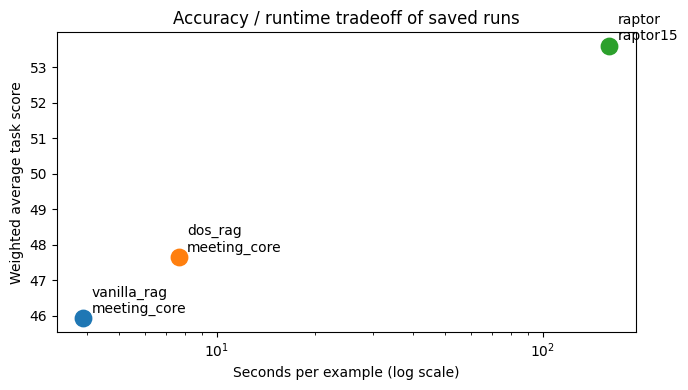

In [6]:
tradeoff_rows = []
for (run, method), group in perf_df.groupby(["run", "method"]):
    total_examples = group["num_examples"].sum()
    weighted_score = (group["score"] * group["num_examples"]).sum() / total_examples if total_examples else None
    total_seconds = group["elapsed_seconds"].sum()
    tradeoff_rows.append(
        {
            "run": run,
            "method": method,
            "total_examples": int(total_examples),
            "weighted_score": weighted_score,
            "seconds_per_example": total_seconds / total_examples if total_examples else None,
            "weighted_avg_input_tokens": (group["avg_input_tokens"] * group["num_examples"]).sum() / total_examples if total_examples else None,
        }
    )

tradeoff_df = pd.DataFrame(tradeoff_rows).sort_values("seconds_per_example")
display(tradeoff_df)

fig, ax = plt.subplots(figsize=(7, 4))
for _, row in tradeoff_df.iterrows():
    ax.scatter(row["seconds_per_example"], row["weighted_score"], s=140)
    ax.annotate(f"{row["method"]}\n{row["run"]}", (row["seconds_per_example"], row["weighted_score"]), textcoords="offset points", xytext=(6, 4))

ax.set_xscale("log")
ax.set_xlabel("Seconds per example (log scale)")
ax.set_ylabel("Weighted average task score")
ax.set_title("Accuracy / runtime tradeoff of saved runs")
plt.tight_layout()
plt.show()


## Fair Overlap Analysis: `vanilla_rag` vs `dos_rag` vs `raptor`

Because RAPTOR only ran on 15 examples per task, the fair comparison is on the **shared example IDs** across:

- `outputs_meeting_core/subset/{vanilla_rag,dos_rag}`
- `outputs_meeting_raptor15/subset/raptor`

for the four overlapping tasks:

- `qasper`
- `narrative_qa`
- `quality`
- `contract_nli`


,task,method,shared_examples,mean_shared_score
0,qasper,vanilla_rag,15,50.7013
1,qasper,dos_rag,15,70.8347
2,qasper,raptor,15,56.2477
3,narrative_qa,vanilla_rag,15,20.0702
4,narrative_qa,dos_rag,15,20.2529
5,narrative_qa,raptor,15,11.4620
6,quality,vanilla_rag,15,66.6667
7,quality,dos_rag,15,73.3333
8,quality,raptor,15,66.6667
9,contract_nli,vanilla_rag,15,80.0000


,task,method,shared_examples,num_unique_wins,num_ties_for_best
0,qasper,vanilla_rag,15,2,7
1,qasper,dos_rag,15,5,7
2,qasper,raptor,15,1,7
3,narrative_qa,vanilla_rag,15,1,11
4,narrative_qa,dos_rag,15,3,11
5,narrative_qa,raptor,15,0,11
6,quality,vanilla_rag,15,1,13
7,quality,dos_rag,15,1,13
8,quality,raptor,15,0,13
9,contract_nli,vanilla_rag,15,0,14


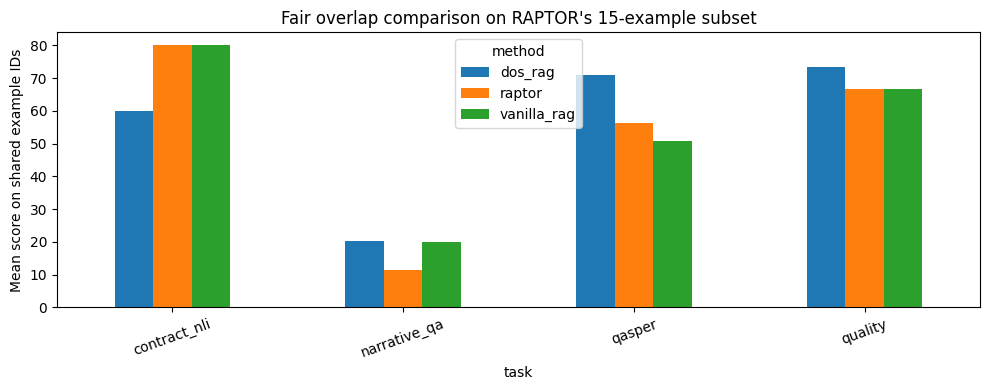

In [7]:
def load_method_rows(run_root, method, task):
    path = run_root / method / task / "results.jsonl"
    return {row["id"]: row for row in load_jsonl(path)}


core_root = RUNS["meeting_core"]["root"]
raptor_root = RUNS["raptor15"]["root"]
overlap_tasks = ["qasper", "narrative_qa", "quality", "contract_nli"]

overlap_rows = []
winner_rows = []

for task in overlap_tasks:
    rows = {
        "vanilla_rag": load_method_rows(core_root, "vanilla_rag", task),
        "dos_rag": load_method_rows(core_root, "dos_rag", task),
        "raptor": load_method_rows(raptor_root, "raptor", task),
    }
    shared_ids = sorted(set.intersection(*(set(r) for r in rows.values())))

    task_scores = {method: [] for method in rows}
    win_counts = {method: 0 for method in rows}
    tie_count = 0

    for ex_id in shared_ids:
        per_method = {method: score_row(task, rows[method][ex_id]) for method in rows}
        best = max(per_method.values())
        best_methods = [m for m, s in per_method.items() if s == best]
        if len(best_methods) == 1:
            win_counts[best_methods[0]] += 1
        else:
            tie_count += 1
        for method, score in per_method.items():
            task_scores[method].append(score)

    for method, scores in task_scores.items():
        overlap_rows.append(
            {
                "task": task,
                "method": method,
                "shared_examples": len(shared_ids),
                "mean_shared_score": round(mean(scores), 4),
            }
        )
        winner_rows.append(
            {
                "task": task,
                "method": method,
                "shared_examples": len(shared_ids),
                "num_unique_wins": win_counts[method],
                "num_ties_for_best": tie_count,
            }
        )

overlap_df = pd.DataFrame(overlap_rows)
winner_df = pd.DataFrame(winner_rows)
display(overlap_df)
display(winner_df)

pivot = overlap_df.pivot(index="task", columns="method", values="mean_shared_score")
pivot.plot(kind="bar", figsize=(10, 4), rot=20)
plt.ylabel("Mean score on shared example IDs")
plt.title("Fair overlap comparison on RAPTOR's 15-example subset")
plt.tight_layout()
plt.show()


## Specific Example Audits

The examples below are pulled directly from saved `results.jsonl` rows. They are chosen because they show clear, concrete differences in method behavior.

I include:

- exact saved prediction
- exact computed per-example score
- prompt ordering when recorded
- selected chunk indices head
- the top retrieved chunk preview

These are useful for building a professor-facing narrative without inventing behavior that is not in the outputs.


In [8]:
def inspect_example(task, example_id):
    method_sources = {
        "vanilla_rag": core_root / "vanilla_rag" / task / "results.jsonl",
        "dos_rag": core_root / "dos_rag" / task / "results.jsonl",
        "raptor": raptor_root / "raptor" / task / "results.jsonl",
    }
    rows = []
    references = None
    for method, path in method_sources.items():
        if not path.exists():
            continue
        method_rows = {row["id"]: row for row in load_jsonl(path)}
        if example_id not in method_rows:
            continue
        row = method_rows[example_id]
        references = row.get("references", [])
        top_chunk = row.get("retrieved_chunks", [])[:1]
        rows.append(
            {
                "method": method,
                "score": round(score_row(task, row), 4),
                "prediction": row.get("prediction", ""),
                "prompt_ordering": row.get("prompt_ordering"),
                "selected_chunk_indices_head": row.get("selected_chunk_indices", [])[:12],
                "top_chunk_preview": top_chunk[0].get("chunk", "")[:220].replace("\n", " ") if top_chunk else "",
            }
        )
    return references, pd.DataFrame(rows)


example_ids = [
    ("qasper", "2df4a045a9cd7b44874340b6fdf9308d3c55327a"),
    ("qasper", "a87a009c242d57c51fc94fe312af5e02070f898b"),
    ("quality", "52845_75VB1ISR_3"),
    ("quality", "30029_F5N22U40_3"),
    ("contract_nli", "3_nda-13"),
    ("contract_nli", "3_nda-1"),
]

for task, example_id in example_ids:
    refs, df = inspect_example(task, example_id)
    print(f"\n### {task} / {example_id}")
    print("references:", refs)
    display(df)



### qasper / 2df4a045a9cd7b44874340b6fdf9308d3c55327a
references: ['Unanswerable', 'They did not use any platform, instead they hired undergraduate students to do the annotation.']


,method,score,prediction,prompt_ordering,selected_chunk_indices_head,top_chunk_preview
0,vanilla_rag,0.0,Amazon Mechanical Turk,retrieval_rank,"[14, 94, 15, 89, 1, 95, 85, 78, 17, 91, 5, 9]",Our work is similar to these work but is appli...
1,dos_rag,25.0,undergraduate students,document_order,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",Our work is similar to these work but is appli...
2,raptor,0.0,Amazon Mechanical Turk,NaN,"[15, 25, 1, 2, 106, 89, 44, 13, 29, 30, 0, 3]","In recent years, a series of work have focuse..."



### qasper / a87a009c242d57c51fc94fe312af5e02070f898b
references: ['logistic regression models', 'logistic regression models based on unigram bag-of-words features (BOW), sentiment signals (SENT), the linguistic features from our earlier analyses (LING), and combinations of these features.']


,method,score,prediction,prompt_ordering,selected_chunk_indices_head,top_chunk_preview
0,vanilla_rag,6.2500,a predictive model to classify dogmatic posts ...,retrieval_rank,"[36, 4, 2, 57, 67, 5, 66, 3, 55, 35, 38, 60]",A predictive model further validates our featu...
1,dos_rag,95.8333,logistic regression models based on unigram ba...,document_order,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",A predictive model further validates our featu...
2,raptor,63.6364,They build a predictive model that compares lo...,NaN,"[4, 0, 37, 38, 52, 55, 34, 70, 53, 6, 8, 63]",We train a predictive model to classify dogmat...



### quality / 52845_75VB1ISR_3
references: ["He feels guilty about sleeping with Eldoria when there's a child in the hut, Deirdre, who knows exactly what's going on."]


...

,method,score,prediction,prompt_ordering,selected_chunk_indices_head,top_chunk_preview
0,vanilla_rag,100.0,Korvin said truths that literally answered the...,retrieval_rank,"[6, 34, 31, 32, 22, 29, 53, 23, 48, 30, 39, 54]","True, every night the guards came in and gave ..."
1,dos_rag,0.0,B Korvin said truths that literally answered t...,document_order,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",The Ruler flashed a look at the technicians h...
2,raptor,0.0,B Korvin said truths that literally answered t...,NaN,"[70, 72, 66, 32, 24, 28, 21, 51, 69, 27, 5, 31]","Korvin, a captive strapped to a lie-detector, ..."



### contract_nli / 3_nda-13
references: ['Entailment']


,method,score,prediction,prompt_ordering,selected_chunk_indices_head,top_chunk_preview
0,vanilla_rag,0.0,Not mentioned,retrieval_rank,"[15, 10, 16, 17, 7, 26, 9, 12, 6, 14, 3, 20]",The Receiving Party undertakes to permit acces...
1,dos_rag,100.0,Entailment,document_order,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",or becomes public knowledge after such disclos...
2,raptor,0.0,Not mentioned,NaN,"[13, 8, 10, 4, 11, 12, 15, 9, 16, 27, 24, 2]",The Receiving Party undertakes to permit acce...



### contract_nli / 3_nda-1
references: ['Entailment']


,method,score,prediction,prompt_ordering,selected_chunk_indices_head,top_chunk_preview
0,vanilla_rag,100.0,Entailment,retrieval_rank,"[6, 9, 16, 7, 10, 15, 12, 13, 14, 22, 26, 18]",In respect of Confidential Information disclos...
1,dos_rag,0.0,Not mentioned,document_order,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",In respect of Confidential Information disclos...
2,raptor,100.0,Entailment,NaN,"[10, 5, 13, 8, 11, 4, 16, 12, 7, 28, 27, 9]",a) To take proper and reasonable measures to e...


## Main Findings

### Accuracy

1. On the 50-example `meeting_core` subset, `dos_rag` beats `vanilla_rag` on 4 of 5 tasks.
   - biggest gain: `quality` (`78.0` vs `70.0`)
   - also better on `qmsum`, `qasper`, and `narrative_qa`
   - worse on `contract_nli` (`66.0` vs `72.0`)

2. On RAPTOR's fair 15-example overlap:
   - `dos_rag` is strongest on `qasper` (`70.8347` shared-score mean)
   - `dos_rag` is also strongest on `quality` (`73.3333`)
   - `vanilla_rag` and `raptor` tie at `80.0` on `contract_nli`, while `dos_rag` drops to `60.0`
   - `dos_rag` and `vanilla_rag` are both clearly above `raptor` on `narrative_qa` in this run

3. The example-level outputs support a mixed mechanism story rather than a universal winner:
   - `qasper / 2df4...`: DOS recovers `undergraduate students`, while vanilla and RAPTOR both answer `Amazon Mechanical Turk`
   - `quality / 52845_75VB1ISR_3`: DOS alone gets the saved reference exactly right
   - `quality / 30029_F5N22U40_3`: vanilla is correct, while DOS and RAPTOR prepend `B` and get exact-match zero
   - `contract_nli / 3_nda-13`: DOS gets `Entailment`, vanilla and RAPTOR both miss
   - `contract_nli / 3_nda-1`: vanilla and RAPTOR get `Entailment`, DOS says `Not mentioned`

### Performance

1. `vanilla_rag` is the fastest among the main retrieval baselines in the 50-example run.
   - about `3.889` seconds per example overall in `meeting_core`

2. `dos_rag` is slower overall than vanilla, but not uniformly slower on every task.
   - about `7.6393` seconds per example overall in `meeting_core`
   - but it is actually faster than vanilla on `quality` and `contract_nli` in the saved run

3. RAPTOR is dramatically slower than both vanilla and DOS in the saved 15-example run.
   - around `129.0` sec/example on `qasper`
   - around `108.6` sec/example on `quality`
   - around `354.4` sec/example on `narrative_qa`

### Interpretation

The current saved outputs support the following reading:

- DOS is a strong accuracy-oriented baseline on these subset tasks, especially for `quality` and `qasper`.
- Its failure mode remains `contract_nli`, where document-order restoration can still hurt clause-local legal reasoning.
- RAPTOR is interesting as a structural baseline, but in the saved run it is expensive enough that its accuracy gains would need to be very large to justify the runtime cost.
- Exact-match formatting is a real issue on `quality`: adding an option letter like `B ...` can zero out an otherwise semantically correct answer.


## Appendix: Secondary DOS / Vanilla Subset Rerun

If `outputs/subset` is the run you meant by "long bench", the table below compares it against `outputs_meeting_core/subset`.

This is best interpreted as a **second DOS/vanilla subset run**, not as a separate method.


In [9]:
if "legacy_subset" in RUNS:
    legacy_root = RUNS["legacy_subset"]["root"]
    rerun_rows = []
    for method in ["vanilla_rag", "dos_rag"]:
        current_report = load_json(core_root / method / "benchmark_report.json")
        legacy_report = load_json(legacy_root / method / "benchmark_report.json")
        for task in current_report["per_task_scores"]:
            rerun_rows.append(
                {
                    "method": method,
                    "task": task,
                    "legacy_subset_score": legacy_report["per_task_scores"].get(task),
                    "meeting_core_score": current_report["per_task_scores"].get(task),
                    "meeting_core_minus_legacy": round(current_report["per_task_scores"].get(task) - legacy_report["per_task_scores"].get(task), 4),
                }
            )
    rerun_df = pd.DataFrame(rerun_rows)
    display(rerun_df)
else:
    print("No legacy_subset run found.")


,method,task,legacy_subset_score,meeting_core_score,meeting_core_minus_legacy
0,vanilla_rag,qmsum,16.650475,16.6505,0.0000
1,vanilla_rag,qasper,43.057548,51.4486,8.3911
2,vanilla_rag,narrative_qa,11.372744,19.5300,8.1573
3,vanilla_rag,quality,70.000000,70.0000,0.0000
4,vanilla_rag,contract_nli,72.000000,72.0000,0.0000
5,dos_rag,qmsum,18.039684,18.2178,0.1781
6,dos_rag,qasper,47.050784,54.4233,7.3725
7,dos_rag,narrative_qa,11.765116,21.6398,9.8747
8,dos_rag,quality,76.000000,78.0000,2.0000
9,dos_rag,contract_nli,64.000000,66.0000,2.0000
